Injection sites: 138  |  With known capacity: 104  |  Imputed with median (41.8 Mt): 34
Elbow at k = 24


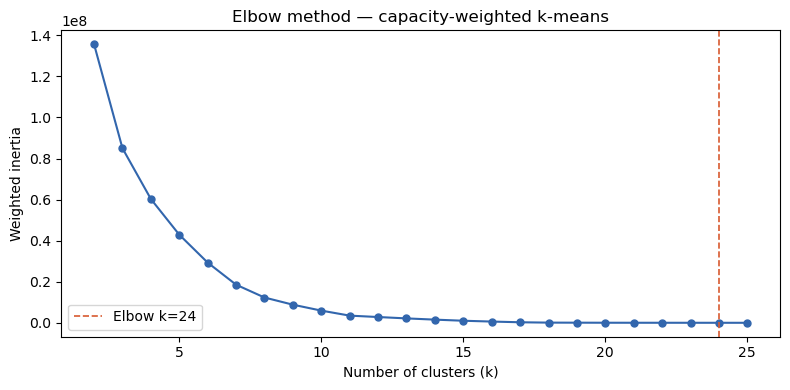


Cluster results (sorted by total storage capacity):
 cluster  centroid_lat  centroid_lng  n_sites  total_cap_Mt nearest_capital  dist_to_capital_km  capital_lat  capital_lng
       2       39.7521       82.6993        4      745913.5        Xinjiang               609.2      43.8256      87.6168
       1       29.7049      124.5648        2      341960.0        Shanghai               341.4      31.2304     121.4737
      12       38.2337      117.7215       25      318173.9         Tianjin               127.3      39.3434     117.3616
       3       37.9067      108.8782       10      257920.9         Ningxia               237.4      38.4722     106.2583
       7       45.3330       87.0245       13      197565.2        Xinjiang               174.1      43.8256      87.6168
       8       34.2186      115.2783        4      178068.0           Henan               152.4      34.7657     113.7531
       4       39.9069      116.4534       10      125551.6         Beijing                 3

In [2]:
# CCS Injection Site Clustering — Weighted K-Means with Elbow Method
# ---------------------------------------------------------------
# Dependencies: pandas, numpy, scikit-learn, matplotlib
# pip install pandas numpy scikit-learn matplotlib

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ── 1. Load & parse ──────────────────────────────────────────────────────────

CSV_PATH = "CPCJ-sht.csv"   # <-- update path if needed

df = pd.read_csv(CSV_PATH, encoding="latin1")

cap_col     = df.columns[-1]   # total storage capacity (Mt CO2)
nearest_col = df.columns[-3]   # nearest storage site ID (links sources → sites)

# ── 2. Build per-site capacity from source rows ───────────────────────────────
# Source rows (CSP / GAS) each carry the capacity of their nearest CCS site.
# We aggregate them back onto the CCS injection sites.

sources = df[df["NEWID"].str.startswith(("CSP", "GAS"), na=False)].copy()

def normalize_ccs_id(s):
    """Convert 'CCS001' → 'CCS1' to match CCS row NEWID format."""
    if pd.isna(s):
        return s
    m = re.match(r"(CCS)(\d+)", str(s))
    return f"CCS{int(m.group(2))}" if m else s

sources["nearest_norm"] = sources[nearest_col].apply(normalize_ccs_id)
cap_lookup = sources.groupby("nearest_norm")[cap_col].first()

# ── 3. Injection site table ───────────────────────────────────────────────────

sites = df[df["NEWID"].str.startswith("CCS", na=False)].copy()
sites["storage_cap_Mt"] = sites["NEWID"].map(cap_lookup)

# Sites with no source mapped get the median capacity as a neutral fallback.
# These sites still exist geologically — we just don't have source assignments yet.
median_cap = sites["storage_cap_Mt"].median()
sites["weight"] = sites["storage_cap_Mt"].fillna(median_cap)

print(f"Injection sites: {len(sites)}  |  "
      f"With known capacity: {sites['storage_cap_Mt'].notna().sum()}  |  "
      f"Imputed with median ({median_cap:.1f} Mt): {sites['storage_cap_Mt'].isna().sum()}")

coords  = sites[["lat1", "lng1"]].values
weights = sites["weight"].values

# ── 4. Elbow method: weighted inertia vs k ────────────────────────────────────

K_MIN, K_MAX = 2, 25
k_range  = range(K_MIN, K_MAX + 1)
inertias = []

np.random.seed(42)
for k in k_range:
    km     = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(coords, sample_weight=weights)
    # Weighted inertia: Σ w_i * ||x_i - c_k||²
    inertia = sum(
        weights[labels == i] @ np.sum((coords[labels == i] - km.cluster_centers_[i]) ** 2, axis=1)
        for i in range(k)
        if (labels == i).any()
    )
    inertias.append(inertia)

inertias = np.array(inertias)

# Elbow via second derivative (largest curvature)
d2       = np.diff(np.diff(inertias))
elbow_k  = int(k_range[np.argmin(d2) + 2])   # +2 corrects for two diff() shifts
print(f"Elbow at k = {elbow_k}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, "o-", color="#3266ad", linewidth=1.5, markersize=5)
ax.axvline(elbow_k, color="#d85a30", linestyle="--", linewidth=1.2, label=f"Elbow k={elbow_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Weighted inertia")
ax.set_title("Elbow method — capacity-weighted k-means")
ax.legend()
plt.tight_layout()
plt.show()

# ── 5. Final clustering ───────────────────────────────────────────────────────
# Change K_FINAL to override the elbow suggestion.

K_FINAL = elbow_k

km_final      = KMeans(n_clusters=K_FINAL, n_init=20, random_state=42)
sites["cluster"] = km_final.fit_predict(coords, sample_weight=weights) + 1  # 1-indexed
centroids     = km_final.cluster_centers_

# ── 6. Distance from each cluster centroid to nearest provincial capital ──────

CAPITALS = {
    "Beijing":       (39.9042, 116.4074),
    "Tianjin":       (39.3434, 117.3616),
    "Hebei":         (38.0428, 114.5149),   # Shijiazhuang
    "Shanxi":        (37.8706, 112.5489),   # Taiyuan
    "Inner Mongolia":(40.8175, 111.7652),   # Hohhot
    "Liaoning":      (41.8057, 123.4315),   # Shenyang
    "Jilin":         (43.8868, 125.3245),   # Changchun
    "Heilongjiang":  (45.7500, 126.6333),   # Harbin
    "Shanghai":      (31.2304, 121.4737),
    "Jiangsu":       (32.0603, 118.7969),   # Nanjing
    "Zhejiang":      (30.2741, 120.1551),   # Hangzhou
    "Anhui":         (31.8612, 117.2847),   # Hefei
    "Fujian":        (26.0745, 119.2965),   # Fuzhou
    "Jiangxi":       (28.6765, 115.9100),   # Nanchang
    "Shandong":      (36.6758, 117.0009),   # Jinan
    "Henan":         (34.7657, 113.7531),   # Zhengzhou
    "Hubei":         (30.5928, 114.3055),   # Wuhan
    "Hunan":         (28.2282, 112.9388),   # Changsha
    "Guangdong":     (23.1291, 113.2644),   # Guangzhou
    "Guangxi":       (22.8170, 108.3665),   # Nanning
    "Hainan":        (20.0440, 110.1999),   # Haikou
    "Chongqing":     (29.5630, 106.5516),
    "Sichuan":       (30.5728, 104.0668),   # Chengdu
    "Guizhou":       (26.5983, 106.7072),   # Guiyang
    "Yunnan":        (25.0453, 102.7097),   # Kunming
    "Tibet":         (29.6525,  91.1322),   # Lhasa
    "Shaanxi":       (34.2658, 108.9541),   # Xi'an
    "Gansu":         (36.0611, 103.8343),   # Lanzhou
    "Qinghai":       (36.6171, 101.7782),   # Xining
    "Ningxia":       (38.4722, 106.2583),   # Yinchuan
    "Xinjiang":      (43.8256,  87.6168),   # Urumqi
}

def haversine_km(lat1, lng1, lat2, lng2):
    """Great-circle distance in km."""
    R   = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi        = np.radians(lat2 - lat1)
    dlambda     = np.radians(lng2 - lng1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

rows = []
for i, (clat, clng) in enumerate(centroids):
    cluster_id = i + 1
    mask       = sites["cluster"] == cluster_id
    n_sites    = int(mask.sum())
    total_cap  = float(weights[mask.values].sum())

    dists = {
        cap: haversine_km(clat, clng, lat, lng)
        for cap, (lat, lng) in CAPITALS.items()
    }
    nearest_cap  = min(dists, key=dists.get)
    nearest_dist = dists[nearest_cap]

    rows.append({
        "cluster":          cluster_id,
        "centroid_lat":     round(clat, 4),
        "centroid_lng":     round(clng, 4),
        "n_sites":          n_sites,
        "total_cap_Mt":     round(total_cap, 1),
        "nearest_capital":  nearest_cap,
        "dist_to_capital_km": round(nearest_dist, 1),
        "capital_lat":      CAPITALS[nearest_cap][0],
        "capital_lng":      CAPITALS[nearest_cap][1],
    })

results = pd.DataFrame(rows).sort_values("total_cap_Mt", ascending=False)
print("\nCluster results (sorted by total storage capacity):")
print(results.to_string(index=False))

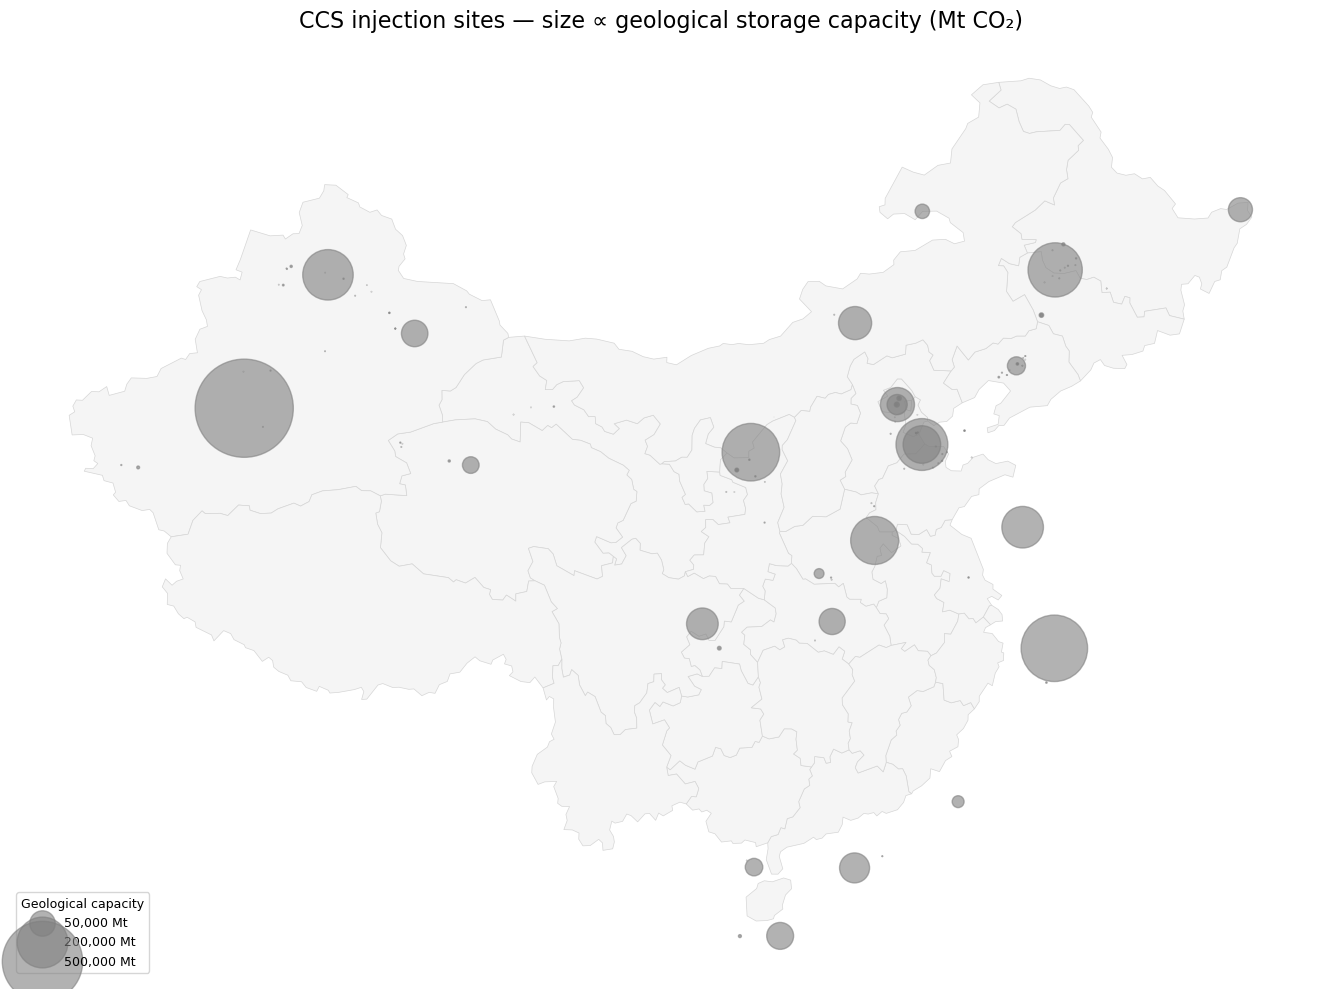

In [23]:
# ── 8. All injection sites — size ∝ geological storage capacity ──────────────
import geopandas as gpd

scaling = 5000

# TCE(Mt) column (index 13) is the geological storage capacity per CCS site
tce_col = df.columns[13]
sites["tce_Mt"] = pd.to_numeric(
    df.loc[df["NEWID"].str.startswith("CCS", na=False), tce_col].values,
    errors="coerce"
)
# Scale to reasonable marker sizes
s = sites["tce_Mt"]
s_norm = (s / s.max()) * scaling  # largest site → 300 pt²

gdf = gpd.read_file("gadm36_CHN_1.json")

fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#d6d6d6", linewidth=0.5)

sc = ax.scatter(
    sites["lng1"], sites["lat1"],
    s=s_norm, color="gray", alpha=0.6, zorder=3
)

# Legend for size scale
for cap in [50_000, 200_000, 500_000]:
    ax.scatter([], [], s=(cap / s.max()) * scaling, color="gray", alpha=0.6,
               label=f"{cap:,} Mt")
ax.legend(title="Geological capacity", loc="lower left", fontsize=9, title_fontsize=9)

ax.set_title("CCS injection sites — size ∝ geological storage capacity (Mt CO₂)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

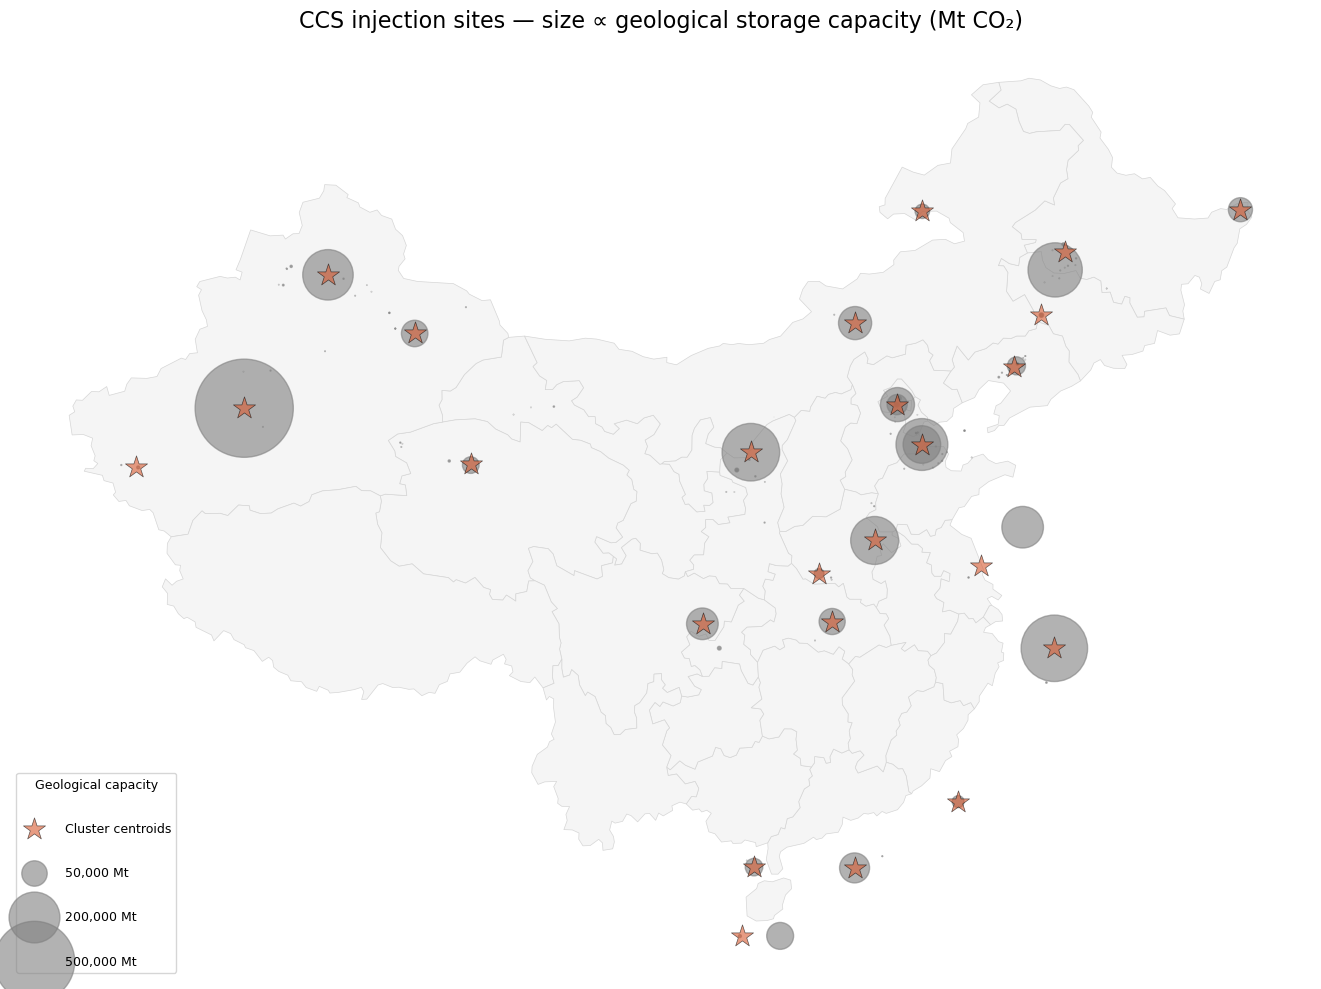

In [33]:
# ── 8. All injection sites — size ∝ geological storage capacity ──────────────
import geopandas as gpd

scaling = 5000

# TCE(Mt) column (index 13) is the geological storage capacity per CCS site.
# Values in the CSV are in Mt → convert to tonnes for model consistency.
tce_col = df.columns[13]
sites["tce_Mt"] = pd.to_numeric(
    df.loc[df["NEWID"].str.startswith("CCS", na=False), tce_col].values,
    errors="coerce"
)
sites["tce_t"] = sites["tce_Mt"] * 1e6   # Mt → t  (model uses tonnes)

s = sites["tce_Mt"]   # use Mt for plotting readability
s_norm = (s / s.max()) * scaling

gdf = gpd.read_file("gadm36_CHN_1.json")

fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#d6d6d6", linewidth=0.5)

ax.scatter(
    sites["lng1"], sites["lat1"],
    s=s_norm, color="gray", alpha=0.6, zorder=3
)

# Cluster centroids as semi-transparent stars
ax.scatter(
    centroids[:, 1], centroids[:, 0],
    marker="*", s=280, color="#d85a30", alpha=0.6,
    edgecolors="black", linewidths=0.5, zorder=5, label="Cluster centroids"
)

# Legend for size scale (Mt labels, but model stores in t)
for cap_Mt in [50_000, 200_000, 500_000]:
    ax.scatter([], [], s=(cap_Mt / s.max()) * scaling, color="gray", alpha=0.6,
               label=f"{cap_Mt:,} Mt")
ax.legend(title="Geological capacity", loc="lower left", fontsize=9, title_fontsize=9,
          labelspacing=2.5, handletextpad=1.5)

ax.set_title("CCS injection sites — size ∝ geological storage capacity (Mt CO₂)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# ── 9. Tunable parameters, cluster naming, distances, and CSV generation ──────
import os

# ─── Tunable cost & financial parameters ──────────────────────────────────────
TRANSPORT_COST_PER_TON_KM  = 0.022   # $/t/km  — pipeline variable O&M
SEQUESTRATION_COST         = 2.93    # $/t     — injection variable O&M
TORTUOSITY                 = 1.3     # great-circle → road/pipeline distance factor

# Pipeline (province → injection site)
# 0.051 M$/(Mt/yr)  =  (10^6 $)/(10^6 t/yr)  =  0.051 $/t  [model capacity unit: t/yr]
PIPELINE_INVESTMENT_COST_M_PER_MT_YR = 0.0510   # M$ / (Mt/yr)  ← input in natural units
PIPELINE_INVESTMENT_COST   = PIPELINE_INVESTMENT_COST_M_PER_MT_YR   # = 0.051 $/t
PIPELINE_FIXED_OM          = 0       # $/t/year
PIPELINE_WACC              = 0.08
PIPELINE_LIFETIME          = 25      # years
PIPELINE_CAPITAL_RECOVERY  = 15      # years
PIPELINE_LOSS_FRACTION     = 0.0

# Injection / sequestration site
# 18 M$/(Mt/yr)  =  (10^6 $)/(10^6 t/yr)  =  18 $/t  [model capacity unit: t/yr]
INJECTION_INVESTMENT_COST_M_PER_MT_YR = 18.0    # M$ / (Mt/yr)  ← input in natural units
INJECTION_INVESTMENT_COST  = INJECTION_INVESTMENT_COST_M_PER_MT_YR  # = 18.0 $/t
INJECTION_FIXED_OM         = 0       # $/t/year
INJECTION_WACC             = 0.08
INJECTION_LIFETIME         = 40      # years
INJECTION_CAPITAL_RECOVERY = 20      # years
INJECTION_RETIREMENT_PERIOD = 2      # years

OUTPUT_DIR = "."   # change to target system path if needed

# ─── Province → model region map ──────────────────────────────────────────────
REGION_MAP = {
    "Beijing":       "Region1Beijing",
    "Tianjin":       "Region2Tianjin",
    "Hebei":         "Region3Hebei",
    "Shanxi":        "Region4Shanxi",
    "Inner Mongolia":"Region5Innermongolia",
    "Liaoning":      "Region6Liaoning",
    "Jilin":         "Region7Jilin",
    "Heilongjiang":  "Region8Heilongjiang",
    "Shanghai":      "Region9Shanghai",
    "Jiangsu":       "Region10Jiangsu",
    "Zhejiang":      "Region11Zhejiang",
    "Anhui":         "Region12Anhui",
    "Fujian":        "Region13Fujian",
    "Jiangxi":       "Region14Jiangxi",
    "Shandong":      "Region15Shandong",
    "Henan":         "Region16Henan",
    "Hubei":         "Region17Hubei",
    "Hunan":         "Region18Hunan",
    "Guangdong":     "Region19Guangdong",
    "Guangxi":       "Region20Guangxi",
    "Hainan":        "Region21Hainan",
    "Chongqing":     "Region22Chongqing",
    "Sichuan":       "Region23Sichuan",
    "Guizhou":       "Region24Guizhou",
    "Yunnan":        "Region25Yunnan",
    "Tibet":         "Region26Tibet",
    "Shaanxi":       "Region27Shaanxi",
    "Gansu":         "Region28Gansu",
    "Qinghai":       "Region29Qinghai",
    "Ningxia":       "Region30Ningxia",
    "Xinjiang":      "Region31Xinjiang",
}

# ─── Ensure tce columns are populated (cell 8 sets these; recompute if needed) ─
if "tce_t" not in sites.columns:
    tce_col = df.columns[13]
    sites["tce_Mt"] = pd.to_numeric(
        df.loc[df["NEWID"].str.startswith("CCS", na=False), tce_col].values,
        errors="coerce"
    )
    sites["tce_t"] = sites["tce_Mt"] * 1e6   # Mt → t

# ─── Name each cluster: nearest province to the largest-capacity site ──────────
def nearest_province_to(lat, lng):
    return min(CAPITALS, key=lambda p: haversine_km(lat, lng, CAPITALS[p][0], CAPITALS[p][1]))

name_counts = {}
cluster_names = {}   # cluster_id (1-indexed) → storage vertex name
for k in range(1, K_FINAL + 1):
    mask = sites["cluster"] == k
    cluster_sites = sites[mask].dropna(subset=["tce_t"])
    if cluster_sites.empty:
        cluster_sites = sites[mask]
    largest = cluster_sites.loc[cluster_sites["tce_t"].idxmax()]
    prov = nearest_province_to(float(largest["lat1"]), float(largest["lng1"]))
    base = prov.replace(" ", "")
    if base in name_counts:
        name_counts[base] += 1
        cluster_names[k] = f"co2_storage_{base}_{name_counts[base]}"
    else:
        name_counts[base] = 1
        cluster_names[k] = f"co2_storage_{base}"

print("Cluster → storage name (capacity in t, used as CO2StorageConstraint rhs_policy):")
for k, name in sorted(cluster_names.items()):
    n_sites = int((sites["cluster"] == k).sum())
    cap_t = int(sites.loc[sites["cluster"] == k, "tce_t"].sum())
    print(f"  Cluster {k:2d}: {name}  ({n_sites} sites, {cap_t:,} t)")

# ─── Assign each province to its nearest cluster centroid ─────────────────────
province_info = {}
for province, (plat, plng) in CAPITALS.items():
    dists = {
        k: haversine_km(plat, plng, centroids[k-1][0], centroids[k-1][1]) * TORTUOSITY
        for k in range(1, K_FINAL + 1)
    }
    nearest_k = min(dists, key=dists.get)
    province_info[province] = {
        "region":          REGION_MAP[province],
        "cluster":         nearest_k,
        "storage_vertex":  cluster_names[nearest_k],
        "dist_km":         round(dists[nearest_k], 1),
        "pipeline_cost":   round(TRANSPORT_COST_PER_TON_KM * dists[nearest_k], 4),
    }

summary_df = pd.DataFrame(province_info).T.reset_index().rename(columns={"index": "Province"})
print("\nProvince assignments:")
print(summary_df[["Province", "region", "cluster", "storage_vertex", "dist_km", "pipeline_cost"]].to_string(index=False))

# ─── co2_pipeline_china.csv ───────────────────────────────────────────────────
pipeline_cols = [
    "Type", "id", "location",
    "edges--transmission_edge--commodity",
    "edges--transmission_edge--has_capacity",
    "edges--transmission_edge--can_expand",
    "edges--transmission_edge--can_retire",
    "edges--transmission_edge--integer_decisions",
    "edges--transmission_edge--constraints--CapacityConstraint",
    "edges--transmission_edge--start_vertex",
    "edges--transmission_edge--end_vertex",
    "edges--transmission_edge--distance",
    "edges--transmission_edge--existing_capacity",
    "edges--transmission_edge--investment_cost",
    "edges--transmission_edge--fixed_om_cost",
    "edges--transmission_edge--variable_om_cost",
    "edges--transmission_edge--wacc",
    "edges--transmission_edge--lifetime",
    "edges--transmission_edge--capital_recovery_period",
    "edges--transmission_edge--loss_fraction",
]

pipeline_rows = []
for province, info in province_info.items():
    region = info["region"]
    pipeline_rows.append({
        "Type":                                                    "OneWayTransmissionLink",
        "id":                                                      f"{region}_CO2_Pipeline",
        "location":                                                region,
        "edges--transmission_edge--commodity":                     "CO2Captured",
        "edges--transmission_edge--has_capacity":                  "TRUE",
        "edges--transmission_edge--can_expand":                    "TRUE",
        "edges--transmission_edge--can_retire":                    "FALSE",
        "edges--transmission_edge--integer_decisions":             "FALSE",
        "edges--transmission_edge--constraints--CapacityConstraint": "TRUE",
        "edges--transmission_edge--start_vertex":                  f"co2_captured_{region}",
        "edges--transmission_edge--end_vertex":                    f"co2_transported_{region}",
        "edges--transmission_edge--distance":                      info["dist_km"],
        "edges--transmission_edge--existing_capacity":             0,
        "edges--transmission_edge--investment_cost":               PIPELINE_INVESTMENT_COST,
        "edges--transmission_edge--fixed_om_cost":                 PIPELINE_FIXED_OM,
        "edges--transmission_edge--variable_om_cost":              info["pipeline_cost"],
        "edges--transmission_edge--wacc":                          PIPELINE_WACC,
        "edges--transmission_edge--lifetime":                      PIPELINE_LIFETIME,
        "edges--transmission_edge--capital_recovery_period":       PIPELINE_CAPITAL_RECOVERY,
        "edges--transmission_edge--loss_fraction":                 PIPELINE_LOSS_FRACTION,
    })

pipeline_df = pd.DataFrame(pipeline_rows, columns=pipeline_cols)
pipeline_path = os.path.join(OUTPUT_DIR, "co2_pipeline_china.csv")
pipeline_df.to_csv(pipeline_path, index=False)
print(f"\nWrote {len(pipeline_df)} rows → {pipeline_path}")

# ─── co2_injection_china.csv ──────────────────────────────────────────────────
injection_cols = [
    "Type", "id", "location",
    "edges--co2_captured_edge--integer_decisions",
    "edges--co2_captured_edge--can_retire",
    "edges--co2_captured_edge--constraints--CapacityConstraint",
    "edges--co2_captured_edge--unidirectional",
    "edges--co2_captured_edge--commodity",
    "edges--co2_captured_edge--can_expand",
    "edges--co2_captured_edge--uc",
    "edges--co2_captured_edge--has_capacity",
    "edges--co2_storage_edge--unidirectional",
    "edges--co2_storage_edge--commodity",
    "edges--co2_storage_edge--has_capacity",
    "transforms--constraints--BalanceConstraint",
    "transforms--timedata",
    "edges--co2_captured_edge--investment_cost",
    "edges--co2_captured_edge--fixed_om_cost",
    "edges--co2_captured_edge--variable_om_cost",
    "edges--co2_captured_edge--wacc",
    "edges--co2_captured_edge--lifetime",
    "edges--co2_captured_edge--capital_recovery_period",
    "edges--co2_captured_edge--retirement_period",
    "edges--co2_captured_edge--existing_capacity",
    "edges--co2_captured_edge--start_vertex",
    "edges--co2_storage_edge--end_vertex",
]

injection_rows = []
for province, info in province_info.items():
    region = info["region"]
    injection_rows.append({
        "Type":                                              "CO2Injection",
        "id":                                                f"{region}_CO2_Injection",
        "location":                                          region,
        "edges--co2_captured_edge--integer_decisions":       "FALSE",
        "edges--co2_captured_edge--can_retire":              "FALSE",
        "edges--co2_captured_edge--constraints--CapacityConstraint": "TRUE",
        "edges--co2_captured_edge--unidirectional":          "TRUE",
        "edges--co2_captured_edge--commodity":               "CO2Captured",
        "edges--co2_captured_edge--can_expand":              "TRUE",
        "edges--co2_captured_edge--uc":                      "FALSE",
        "edges--co2_captured_edge--has_capacity":            "TRUE",
        "edges--co2_storage_edge--unidirectional":           "TRUE",
        "edges--co2_storage_edge--commodity":                "CO2Captured",
        "edges--co2_storage_edge--has_capacity":             "FALSE",
        "transforms--constraints--BalanceConstraint":        "TRUE",
        "transforms--timedata":                              "CO2Captured",
        "edges--co2_captured_edge--investment_cost":         INJECTION_INVESTMENT_COST,
        "edges--co2_captured_edge--fixed_om_cost":           INJECTION_FIXED_OM,
        "edges--co2_captured_edge--variable_om_cost":        SEQUESTRATION_COST,
        "edges--co2_captured_edge--wacc":                    INJECTION_WACC,
        "edges--co2_captured_edge--lifetime":                INJECTION_LIFETIME,
        "edges--co2_captured_edge--capital_recovery_period": INJECTION_CAPITAL_RECOVERY,
        "edges--co2_captured_edge--retirement_period":       INJECTION_RETIREMENT_PERIOD,
        "edges--co2_captured_edge--existing_capacity":       0,
        "edges--co2_captured_edge--start_vertex":            f"co2_transported_{region}",
        "edges--co2_storage_edge--end_vertex":               info["storage_vertex"],
    })

injection_df = pd.DataFrame(injection_rows, columns=injection_cols)
injection_path = os.path.join(OUTPUT_DIR, "co2_injection_china.csv")
injection_df.to_csv(injection_path, index=False)
print(f"Wrote {len(injection_df)} rows → {injection_path}")